# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Process code (scoring, resumability/status tracking, disk-retention cleanup, the sweep loop itself) lives in `AA_cam_pose_sweeps.py`, next to this notebook -- import it, don't copy it, so fixes/improvements there apply to every per-case copy of this notebook automatically. This notebook only holds what varies per case:
- **Config**: `case_name`, frame range, `CAM_POSES`, `TECHNIQUE_ORDER`, `FLAGS`, and `DATA_STORAGE` (what to keep on disk afterwards vs delete).
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process -- see `AA_cam_pose_sweeps.py`'s Resumability infrastructure section.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep. Stays notebook-side since it's meant to be freely tweaked per case.

`align_and_score` and the trace loaders are reused from `F_post_recon_processing.py`/`AA_cam_pose_sweeps.py`, same functions `AA_Cam_pose_estimate_batches.ipynb` uses.

In [1]:
%load_ext autoreload
%autoreload 2

## Config

In [2]:
import sys
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)

from A_Config import set_case, case_dir
from Two2D.B_video_processing import video_fps
from templates.AA_cam_pose_sweeps import reset_sweep_state, run_density_sweep

case_name = "11_walk_home_1"
experiment = "Cam_pose_v08_dist"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]


# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).

start_3D_recon = 12000
interframe_interval = 60 
max_dur = interframe_interval*201+start_3D_recon
n_steps = 10
step = interframe_interval * (200 // n_steps)
print(step)
end_3D_recon_list = []
dur = interframe_interval
while start_3D_recon + dur < max_dur:
    end_3D_recon_list.append(start_3D_recon + dur)
    dur *= 2
end_3D_recon_list.append(max_dur)
print("doubler",end_3D_recon_list)

#end_3D_recon_list = range((25*interval)+ start_3D_recon, max_dur, interval * (200 // n_steps))

end_3D_recon_list = list(range(start_3D_recon + step, max_dur, step))
print(end_3D_recon_list)
fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")
print("total frames", max_dur-start_3D_recon)
# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic in run_density_sweep (more frames -> more GPU memory).
#CAM_POSES = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
     "CUT3R":       True,
    "CUT3R_Revisit": True,
    "lingbot-map": True,
    "VGGT-Omega":  True,
    "MegaSaM":     True,
    "VGGT":        True,
}

# What the sweep keeps on disk afterwards vs deletes -- see AA_cam_pose_sweeps.py's
# _cleanup_technique_output for exactly what each toggle controls.
DATA_STORAGE = {
    "keep_inputs":     True,  # extracted frames per density (020_frames_for_cam_poses)
    "keep_recon_data": True,  # full heavy technique output (images/depth/point-clouds/caches)
    "keep_cam_poses":  True,   # lightweight <technique_output>/CAM_poses/poses.csv per density
    "full_pose":       True,  # rotation too, not just translation, in the retained CSV
    "render_bev":      True,   # one <technique_output>/BEV/bev.png per technique/density --
                                # every technique gets a Reconstruction (natively for VGGT-Omega,
                                # via F_transpose_to_recon_objects.py adapters for the rest), then
                                # P_projection_mapping.BEV_tile_render_PM renders from it. Cheap
                                # to keep even when keep_recon_data=False.
}
out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)

project_root: /workspace/project


/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1200
doubler [12060, 12120, 12240, 12480, 12960, 13920, 15840, 19680, 24060]
[13200, 14400, 15600, 16800, 18000, 19200, 20400, 21600, 22800, 24000]
video fps: 30.080
total frames 12060


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [3]:
CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

reset_sweep_state(case_name, experiment, confirm=CONFIRM_DELETE)

confirm=False -- dry run only, nothing deleted. Would remove:
  rmtree /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/034_VGGT_output/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/035_CUT3R_output/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/035_VGGT_O_output/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/036_lingbot_map_output/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/036_MEGASAM_output/Cam_pose_v08_dist
  rmtree /workspace/project/Data/11_walk_home_1/080_Experiments/Cam_pose_v08_dist


## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [4]:
from Q_GPS_processing import csv_to_GPS_dict

gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

101 GT anchors loaded from GPS_tags.csv


## Part 2 -- Sweep (expensive, resumable, run once/rarely)

`run_density_sweep` (in `AA_cam_pose_sweeps.py`) gives each `cam_poses` value its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [5]:
from AA_cam_pose_sweeps import run_distance_sweep
run_distance_sweep(
    case_name, experiment, video_path, start_3D_recon, end_3D_recon_list,interframe_interval,
     TECHNIQUE_ORDER, FLAGS, DATA_STORAGE, project_root, GPS_dict,
)

[VGGT @ 21600] kernel died mid-attempt last run -- presumed GPU OOM (restart the kernel now if you haven't already)
[VGGT @ 22800] precautionary skip (OOM upstream at cam_poses=21600)
[VGGT @ 24000] precautionary skip (OOM upstream at cam_poses=21600)
end frame =13200: frames already present in /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v08_dist/poses_13200, skipping extraction
[CUT3R @ 13200] already success, skipping
[CUT3R_Revisit @ 13200] already success, skipping
[lingbot-map @ 13200] already success, skipping
[VGGT-Omega @ 13200] already success, skipping
[MegaSaM @ 13200] already success, skipping
[VGGT @ 13200] already success, skipping
end frame =14400: frames already present in /workspace/project/Data/11_walk_home_1/020_frames_for_cam_poses/Cam_pose_v08_dist/poses_14400, skipping extraction
[CUT3R @ 14400] already success, skipping
[CUT3R_Revisit @ 14400] already success, skipping
[lingbot-map @ 14400] already success, skipping
[VGGT-Omega @ 1440

CUT3R:   0%|          | 0/180 [00:00<?, ?it/s]/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████| 180/180 [00:39<00:00,  4.53it/s]


State saved → /workspace/project/Data/11_walk_home_1/035_CUT3R_output/Cam_pose_v08_dist/poses_22800/cut3r_state.pt
Done. 180 frames in 0.7 min  (0.22 s/frame)
Output: /workspace/project/Data/11_walk_home_1/035_CUT3R_output/Cam_pose_v08_dist/poses_22800
min depth tensor(0.4864, device='cuda:0')
torch.Size([24547756, 3])
mins, maxes and ranges -68.55323162078858 51.288571739196776 119.84180335998536 -16.30090045928955 401.4441614151001 417.74506187438965
scale - original 22.143489913337007
min depth tensor(0.4864, device='cuda:0')
torch.Size([24547756, 3])
mins, maxes and ranges -68.55323162078858 51.288571739196776 119.84180335998536 -16.30090045928955 401.4441614151001 417.74506187438965
scale - original 22.143489913337007
min depth tensor(0.4864, device='cuda:0')
torch.Size([23883300, 3])
mins, maxes and ranges -66.28210754394532 51.180422973632815 117.46253051757813 -16.30090045928955 401.4441614151001 417.74506187438965
scale - original 22.061844955948896
min depth tensor(0.4864, de

CUT3R:   0%|          | 0/180 [00:00<?, ?it/s]/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspace/project/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████| 180/180 [00:26<00:00,  6.73it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


...

################################
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
median_hessian, median_calib  tensor(8802.8027, device='cuda:0') tensor([4.5624e+18], device='cuda:0')
_opt_intr  True  use_mono  False  alpha  0.0
################## KEYFRAME BUNDLE ADJUSTMENT ################################  use_mono  False
Global BA Iteration #1
Global BA Iteration #2
Global BA Iteration #3
Global BA Iteration #4
Global BA Iteration #5
Global BA Iteration #6
Global BA Iteration #7
Global BA Iteration #8
Global BA Iteration #9
Global BA Iteration #10
Global BA Iteration #11
Global BA Iteration #12
Global BA Iteration #13
Global BA Iteration #14
Global BA Iteration #15
Global BA Iteration #16
Global BA Iteration #17
Global BA Iteration #18
Global BA Iteration #19
Global BA Iteration #20

GLOBAL FRAME BA ####

188it [00:05, 33.98it/s]
  0%|          | 0/187 [00:00<?, ?it/s]/workspace/project/.conda_envs/mega_sam/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995026/work/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 173/173 [00:14<00:00, 11.94it/s]


  RAFT flow done in 92s
$ conda run --no-capture-output -n mega_sam python cvd_opt/cvd_opt.py --scene_name 11_walk_home_1 --w_grad 2.0 --w_normal 5.0
CVD optimisation: 11_walk_home_1
step  0 1.6624444723129272
step  20 1.2904011011123657
step  40 1.072059154510498
step  60 1.044102668762207
step  80 0.8564348816871643
step  0 0.7099099159240723
step  20 0.7137047052383423
step  40 0.6359717845916748
step  60 0.6036137342453003
step  80 0.586065411567688
step  100 0.5718129277229309
step  120 0.5600064396858215
step  140 0.5504269003868103
step  160 0.5417652130126953
step  180 0.5342391133308411
step  200 0.5270640254020691
step  220 0.5213044881820679
step  240 0.5150248408317566
step  260 0.5098415017127991
step  280 0.5050519108772278
step  300 0.5002869963645935
step  320 0.49594977498054504
step  340 0.49220559000968933
step  360 0.4882524907588959
step  380 0.48464423418045044


/workspace/project/Models/mega-sam/cvd_opt/cvd_opt.py:470: RuntimeWarning: overflow encountered in cast
  depths=np.clip(np.float16(1.0 / disp_data_opt), 1e-3, 1e2),


  CVD optimisation done in 192s
Output: /workspace/project/Data/11_walk_home_1/036_MEGASAM_output/Cam_pose_v08_dist/poses_24000/11_walk_home_1_sgd_cvd_hr.npz
min depth tensor(0.0010, device='cuda:0')
torch.Size([35913491, 3])
mins, maxes and ranges -96.25127372741699 82.64743003845214 178.89870376586913 -7.911361882317578 166.16300529285218 174.07436717516975
scale - original 33.95922747783367
min depth tensor(0.0010, device='cuda:0')
torch.Size([34210776, 3])
mins, maxes and ranges -96.24524116516113 82.5207462310791 178.76598739624023 -7.911361882317578 166.16300529285218 174.07436717516975
scale - original 33.15672323384127
min depth tensor(0.0010, device='cuda:0')
torch.Size([32408375, 3])
mins, maxes and ranges -96.17000885009766 80.9408676147461 177.11087646484376 -7.911361882317578 166.16300529285218 174.07436717516975
scale - original 32.42191023903384
min depth tensor(0.0010, device='cuda:0')
torch.Size([28804805, 3])
mins, maxes and ranges -96.17000885009766 80.9408676147461 

## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

# line

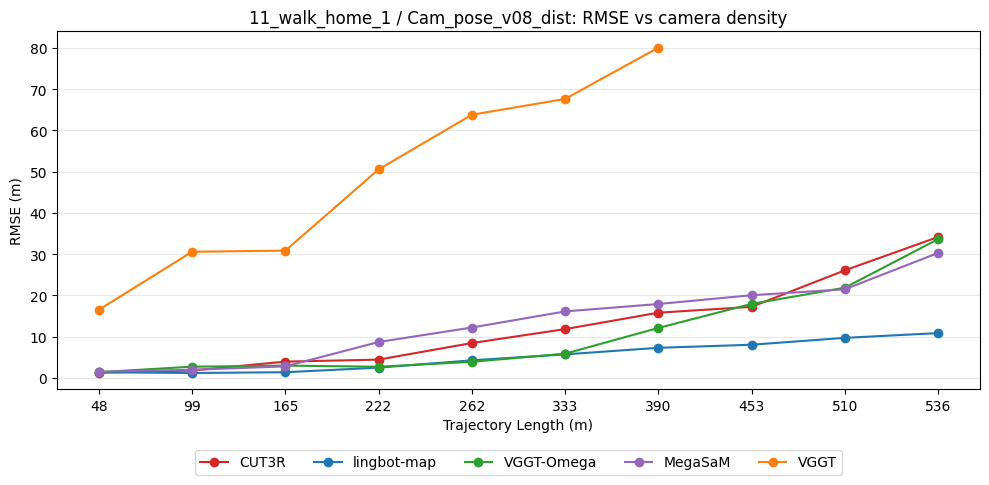

In [9]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir



set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / f"{experiment}" / f"{experiment}_results.csv"

TECHNIQUE_ORDER = ["CUT3R", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["trajectory length (m)"].unique())

x = np.arange(len(cam_poses_vals))

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = df[df["technique"] == technique].set_index("trajectory length (m)")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.plot(x, heights, marker="o", label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0f}" for v in cam_poses_vals])
ax.set_xlabel("Trajectory Length (m)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / f"{case_name}_{experiment}_RMSE_distance.svg", format="svg", bbox_inches="tight")